DECISION TREE

Write a program to demonstrate the working of the Decision Tree–based ID3 algorithm using an 
appropriate dataset. 

In [15]:
import pandas as pd
import numpy as np
import pprint
from sklearn import tree
import matplotlib.pyplot as plt

In [16]:
eps = np.finfo(float).eps
from numpy import log2 as log

In [17]:
def find_entropy(df):
    Class = df.keys()[-1]
    entropy = 0
    values = df[Class].unique()
    for value in values:
        fraction = df[Class].value_counts()[value] / len(df[Class])
        entropy += -fraction * np.log2(fraction)
    return entropy

In [18]:
def find_entropy_attribute(df, attribute):
    Class = df.keys()[-1]
    target_variables = df[Class].unique()
    variables = df[attribute].unique()
    entropy2 = 0
    for variable in variables:
        entropy = 0
        for target_variable in target_variables:
            num = len(df[attribute][df[attribute] == variable][df[Class] == target_variable])
            den = len(df[attribute][df[attribute] == variable])
            fraction = num / (den + eps)
            entropy += -fraction * log(fraction + eps)
        fraction2 = den / len(df)
        entropy2 += -fraction2 * entropy
    return abs(entropy2)

In [19]:
def find_best_threshold(df, attribute):
    Class = df.keys()[-1]
    values = sorted(df[attribute].unique())
    if len(values) < 2:
        return None, -1

    base_entropy = find_entropy(df)
    best_gain = -1
    best_threshold = None

    for i in range(len(values) - 1):
        threshold = (values[i] + values[i + 1]) / 2
        left = df[df[attribute] <= threshold]
        right = df[df[attribute] > threshold]

        if left.empty or right.empty:
            continue

        weighted_entropy = (
            (len(left) / len(df)) * find_entropy(left)
            + (len(right) / len(df)) * find_entropy(right)
        )
        gain = base_entropy - weighted_entropy

        if gain > best_gain:
            best_gain = gain
            best_threshold = threshold

    return best_threshold, best_gain


In [20]:
def find_winner(df):
    IG = []
    for key in df.keys()[:-1]:
        _, gain = find_best_threshold(df, key)
        IG.append(gain)

    best_index = np.argmax(IG) if IG else -1
    return df.keys()[:-1][best_index] if best_index != -1 else None


In [21]:
def buildTree(df, tree=None):
    Class = df.keys()[-1]
    if len(df[Class].unique()) == 1:
        return df[Class].iloc[0]

    if len(df.columns) == 1:
        return df[Class].mode().iloc[0]

    node = find_winner(df)
    if node is None:
        return df[Class].mode().iloc[0]

    threshold, _ = find_best_threshold(df, node)
    if threshold is None:
        return df[Class].mode().iloc[0]

    left = df[df[node] <= threshold].reset_index(drop=True)
    right = df[df[node] > threshold].reset_index(drop=True)

    if tree is None:
        tree = {}

    tree[node] = {}
    tree[node][f'<= {threshold}'] = buildTree(left) if not left.empty else df[Class].mode().iloc[0]
    tree[node][f'> {threshold}'] = buildTree(right) if not right.empty else df[Class].mode().iloc[0]

    return tree


In [22]:
df = pd.read_csv('ServiceTest.csv')
print("\nGiven dataset:\n\n", df)

decision_tree = buildTree(df)

print('The resultant decision tree is:')
pprint.pprint(decision_tree)


Given dataset:

         OilQual  EnginePerf  NormMileage    TyreWear    HVACwear Service
0     45.773338   49.936615    49.777581   48.263851   50.952072      No
1      4.987185    7.891003     6.588986    9.493161    3.240262      No
2      4.987185    4.891003     7.308986    8.373161    2.780262      No
3    106.388821  104.454032   103.051485  106.282658  105.536843      No
4    104.388821  103.744032   103.051485  106.132658  105.776843      No
..          ...         ...          ...         ...         ...     ...
130  103.388821  103.934032   102.941485  106.172658  105.536843      No
131    5.987185    6.081003     6.588986    8.373161    0.370262      No
132   25.385516   27.418265    32.309536   30.036162   31.311275     Yes
133   45.533338   49.666615    49.347581   51.263851   47.922072      No
134  104.388821  104.504032   102.461485  106.172658  105.536843      No

[135 rows x 6 columns]
The resultant decision tree is:
{'OilQual': {'<= 84.401051645': {'OilQual': {'<= 5

In [23]:
# Use a row from the same dataset so the feature names match the tree exactly.
test = df.drop(columns=['Service']).iloc[0].to_dict()



In [24]:
def func(test, tree, default=None):
    if not isinstance(tree, dict) or not tree:
        return default

    for attribute, branches in tree.items():
        if attribute not in test:
            continue

        value = test[attribute]

        for branch_label, child in branches.items():
            if branch_label.startswith('<='):
                threshold = float(branch_label.split('<=')[1].strip())
                if value <= threshold:
                    if isinstance(child, dict):
                        return func(test, child, default)
                    return child
            elif branch_label.startswith('>'):
                threshold = float(branch_label.split('>')[1].strip())
                if value > threshold:
                    if isinstance(child, dict):
                        return func(test, child, default)
                    return child

    return default

In [25]:
ans = func(test, decision_tree)
print('Prediction for the sample row:', ans)


Prediction for the sample row: No


In [26]:
# Custom prediction example
custom_test = {
    'OilQual': 50,
    'EnginePerf': 60,
    'NormMileage': 55,
    'TyreWear': 52,
    'HVACwear': 48
}
custom_prediction = func(custom_test, decision_tree)
print('Custom tree prediction:', custom_prediction)

Custom tree prediction: No


In [27]:
# Plot the decision tree using matplotlib (no external Graphviz binary required)
X = df.drop(columns=['Service'])
y = df['Service']

clf = tree.DecisionTreeClassifier(random_state=42)
clf.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

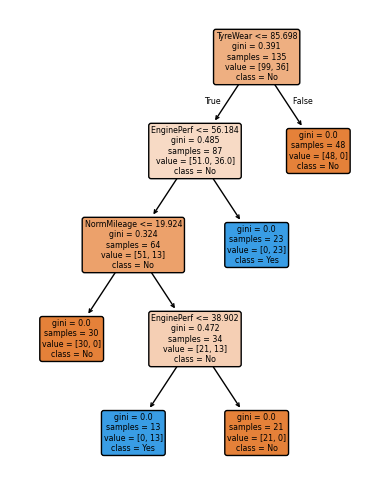

In [28]:
plt.figure(figsize=(4, 5))
tree.plot_tree(
    clf,
    feature_names=X.columns,
    class_names=sorted(y.unique()),
    filled=True,
    rounded=True,
)
plt.tight_layout()
#plt.savefig('decision_tree_plot.png')

#print('Decision tree plot saved as decision_tree_plot.png')
plt.show()